In [1]:
import os
import pandas as pd
from scipy.stats import kruskal

In [2]:
folder = r"E:\CSV\merged"
files = os.listdir(folder)

df_names = ["CaSupp_25", "konv", "monoe_120kev", "monoe_80kev", "monoe_40kev"]

In [3]:
def kruskal_for_pair(df_myeloma, df_healthy):
    num_cols = df_healthy.select_dtypes(include=["number"]).columns
    results = []

    for col in num_cols:
        if "shape" in col:
            continue

        myeloma_group = df_myeloma[col].dropna()
        healthy_group = df_healthy[col].dropna()

        stat, p_value = kruskal(myeloma_group, healthy_group)

        if p_value < 0.05:
            results.append({
                "feature": col,
                "statistic": stat,
                "p_value": p_value
            })

    return pd.DataFrame(results).sort_values("p_value")

In [4]:
all_results = {}
for name in df_names:
    myeloma_path = os.path.join(folder, f"merged_{name}_radiomics_spine_lesions_features.csv")
    healthy_path = os.path.join(folder, f"merged_{name}_radiomics_spine_vertebrae_features.csv")

    df_myeloma = pd.read_csv(myeloma_path)
    df_healthy = pd.read_csv(healthy_path)

    results_df = kruskal_for_pair(df_myeloma, df_healthy)

    all_results[name] = results_df

In [5]:
for name, df in all_results.items():
    print(name)
    print(df.head(5))
    print()

CaSupp_25
                                    feature   statistic       p_value
10              original_firstorder_Minimum  122.577058  1.725806e-28
102             gradient_firstorder_Minimum  117.365542  2.387489e-27
0          original_firstorder_10Percentile  107.380756  3.673563e-25
4    original_firstorder_InterquartileRange  107.265088  3.894346e-25
9                original_firstorder_Median  107.261208  3.901978e-25

konv
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.279101  3.866906e-25
6              original_firstorder_Maximum  107.265734  3.893075e-25
9               original_firstorder_Median  107.264010  3.896465e-25
1         original_firstorder_90Percentile  107.262932  3.898584e-25
11               original_firstorder_Range  107.259268  3.905799e-25

monoe_120kev
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.283630  3.858081e-2

In [6]:
from scipy.stats import ttest_ind
import pandas as pd

def ttest_for_pair(df_myeloma, df_healthy):
    num_cols = df_healthy.select_dtypes(include=["number"]).columns
    results = []

    for col in num_cols:
        if "shape" in col:
            continue

        myeloma_group = df_myeloma[col].dropna()
        healthy_group = df_healthy[col].dropna()

        stat, p_value = ttest_ind(myeloma_group, healthy_group, equal_var=False)

        if p_value < 0.05:
            results.append({
                "feature": col,
                "statistic": stat,
                "p_value": p_value
            })

    return pd.DataFrame(results).sort_values("p_value")

In [7]:
all_results = {}
for name in df_names:
    myeloma_path = os.path.join(folder, f"merged_{name}_radiomics_spine_lesions_features.csv")
    healthy_path = os.path.join(folder, f"merged_{name}_radiomics_spine_vertebrae_features.csv")

    df_myeloma = pd.read_csv(myeloma_path)
    df_healthy = pd.read_csv(healthy_path)

    results_df = kruskal_for_pair(df_myeloma, df_healthy)

    all_results[name] = results_df

In [8]:
for name, df in all_results.items():
    print(name)
    print(df.head(5))
    print()

CaSupp_25
                                    feature   statistic       p_value
10              original_firstorder_Minimum  122.577058  1.725806e-28
102             gradient_firstorder_Minimum  117.365542  2.387489e-27
0          original_firstorder_10Percentile  107.380756  3.673563e-25
4    original_firstorder_InterquartileRange  107.265088  3.894346e-25
9                original_firstorder_Median  107.261208  3.901978e-25

konv
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.279101  3.866906e-25
6              original_firstorder_Maximum  107.265734  3.893075e-25
9               original_firstorder_Median  107.264010  3.896465e-25
1         original_firstorder_90Percentile  107.262932  3.898584e-25
11               original_firstorder_Range  107.259268  3.905799e-25

monoe_120kev
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.283630  3.858081e-2

# HEALTHY || STAGE I. || STAGE II. || STAGE III.

Top 10 najsignifikantnejších príznakov:
                                   Feature     H-stat   p-value
74   original_gldm_DependenceNonUniformity  23.196585  0.000037
150  gradient_glszm_GrayLevelNonUniformity  22.565854  0.000050
167  gradient_gldm_DependenceNonUniformity  22.473659  0.000052
65    original_glszm_SizeZoneNonUniformity  22.104878  0.000062
143  gradient_glrlm_RunLengthNonUniformity  21.815122  0.000071
0         original_firstorder_10Percentile  21.793666  0.000072
158   gradient_glszm_SizeZoneNonUniformity  21.621951  0.000078
107        gradient_firstorder_TotalEnergy  21.450732  0.000085
57   original_glszm_GrayLevelNonUniformity  21.134634  0.000099
50   original_glrlm_RunLengthNonUniformity  20.536098  0.000131


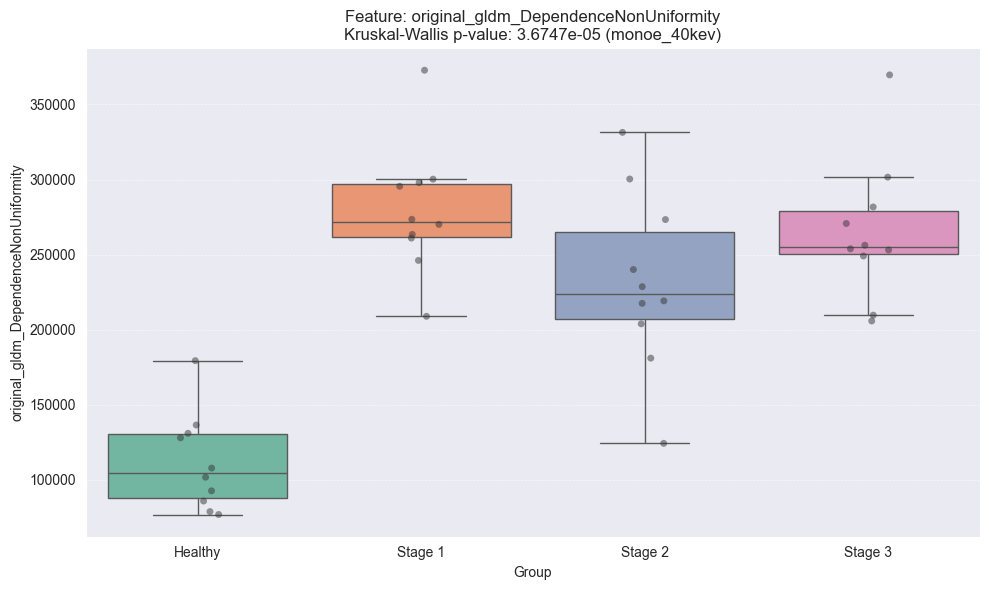

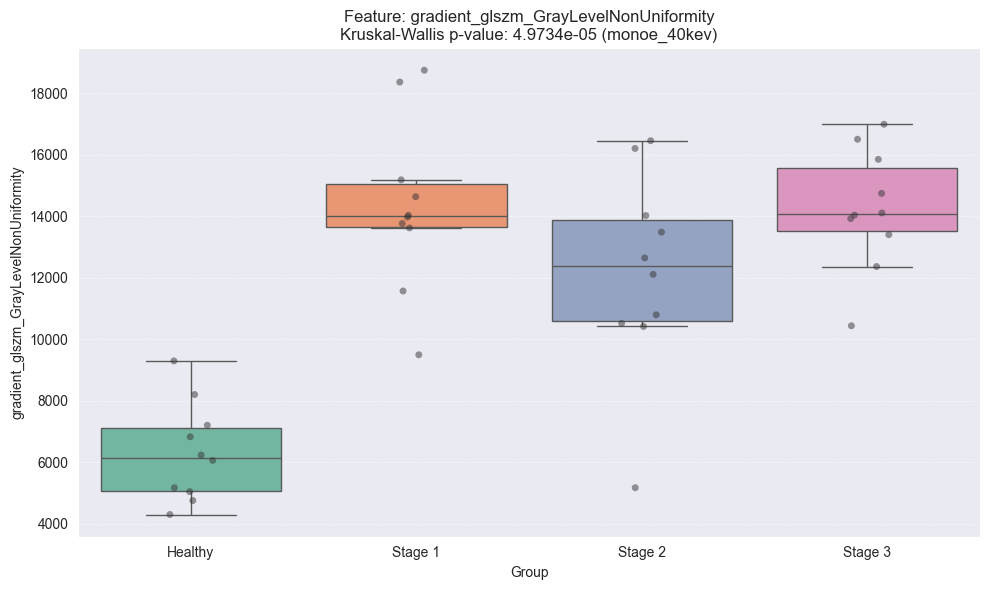

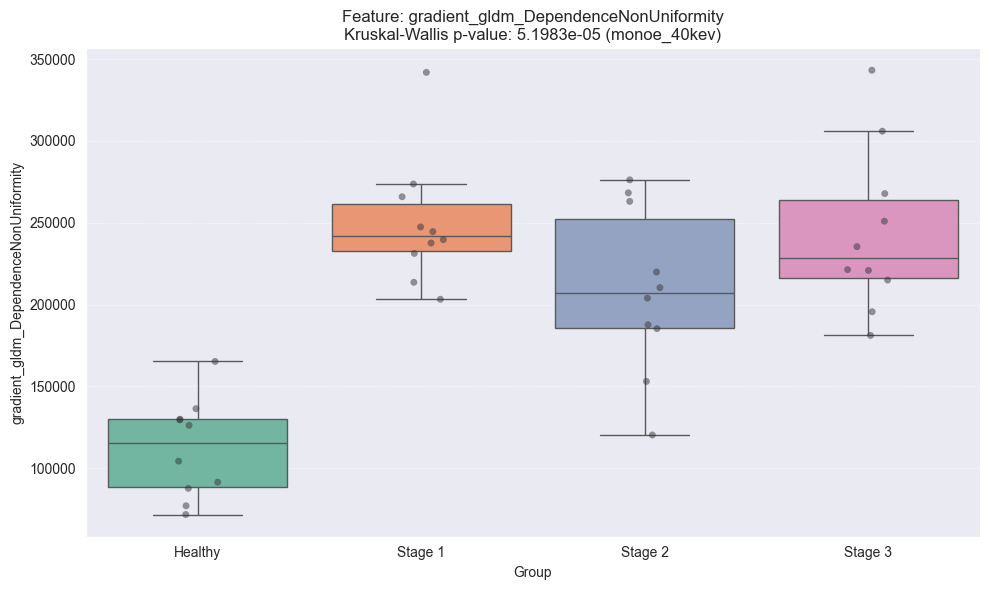

In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "monoe_40kev"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(3).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e} ({selected_img})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Top 10 najsignifikantnejších príznakov:
                                               Feature     H-stat   p-value
178  gradient_gldm_SmallDependenceLowGrayLevelEmphasis  24.279512  0.000022
166              gradient_gldm_DependenceNonUniformity  22.987317  0.000041
149              gradient_glszm_GrayLevelNonUniformity  22.672683  0.000047
74               original_gldm_DependenceNonUniformity  22.382927  0.000054
65                original_glszm_SizeZoneNonUniformity  22.216098  0.000059
142              gradient_glrlm_RunLengthNonUniformity  22.046341  0.000064
106                    gradient_firstorder_TotalEnergy  21.880976  0.000069
50               original_glrlm_RunLengthNonUniformity  21.551707  0.000081
57               original_glszm_GrayLevelNonUniformity  21.458049  0.000085
51     original_glrlm_RunLengthNonUniformityNormalized  20.998537  0.000105


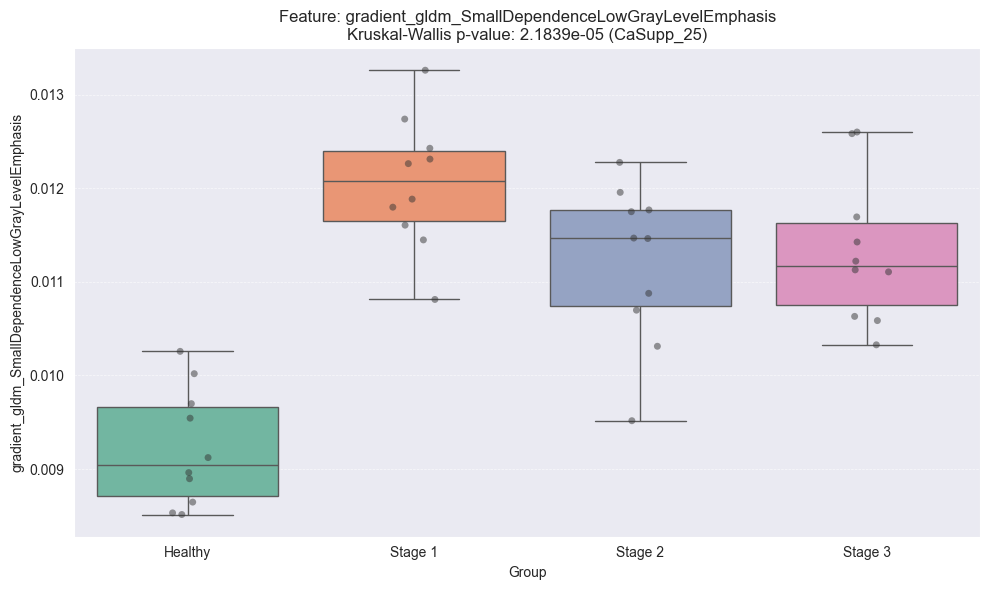

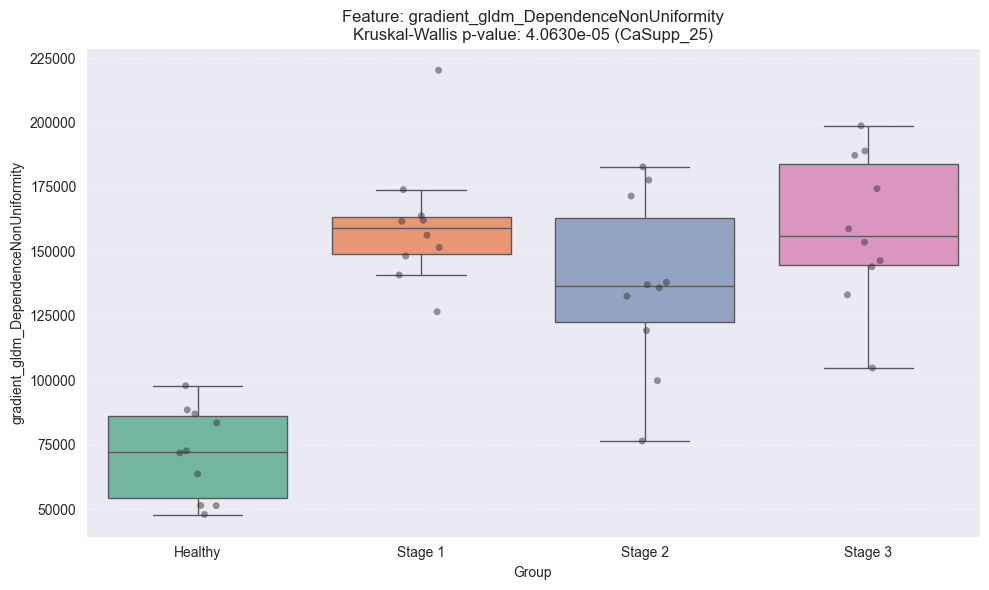

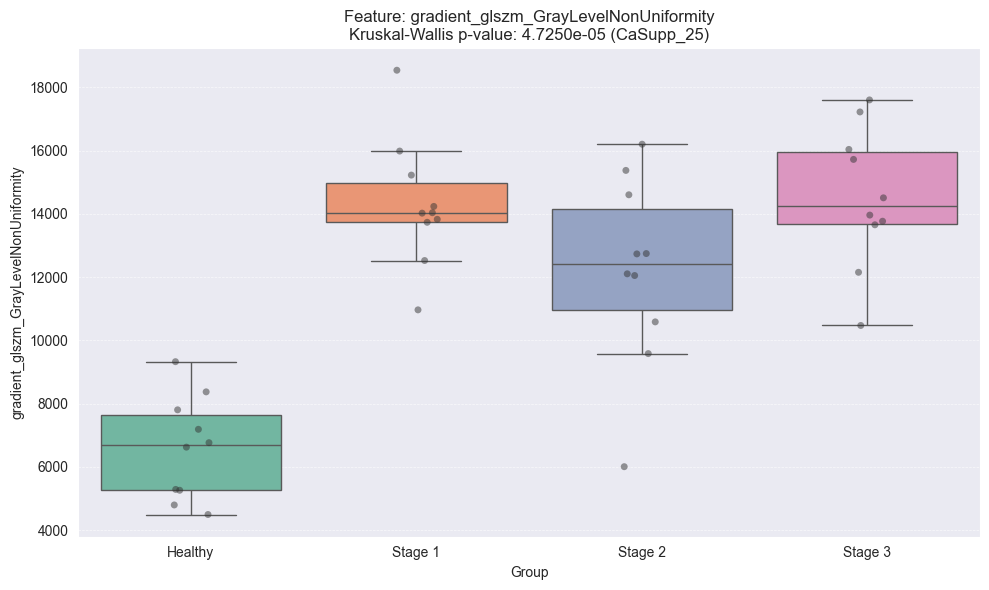

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "CaSupp_25"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(3).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e} ({selected_img})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Top 10 najsignifikantnejších príznakov:
                                   Feature     H-stat   p-value
124                     gradient_glcm_Imc1  25.273171  0.000014
77        original_gldm_DependenceVariance  24.920488  0.000016
131       gradient_glcm_MaximumProbability  24.721463  0.000018
170       gradient_gldm_DependenceVariance  24.616098  0.000019
66    original_glszm_SizeZoneNonUniformity  24.563415  0.000019
147             gradient_glrlm_RunVariance  24.481463  0.000020
38        original_glcm_MaximumProbability  24.463902  0.000020
81   original_gldm_LargeDependenceEmphasis  24.367317  0.000021
54              original_glrlm_RunVariance  24.354146  0.000021
46          original_glrlm_LongRunEmphasis  24.354146  0.000021


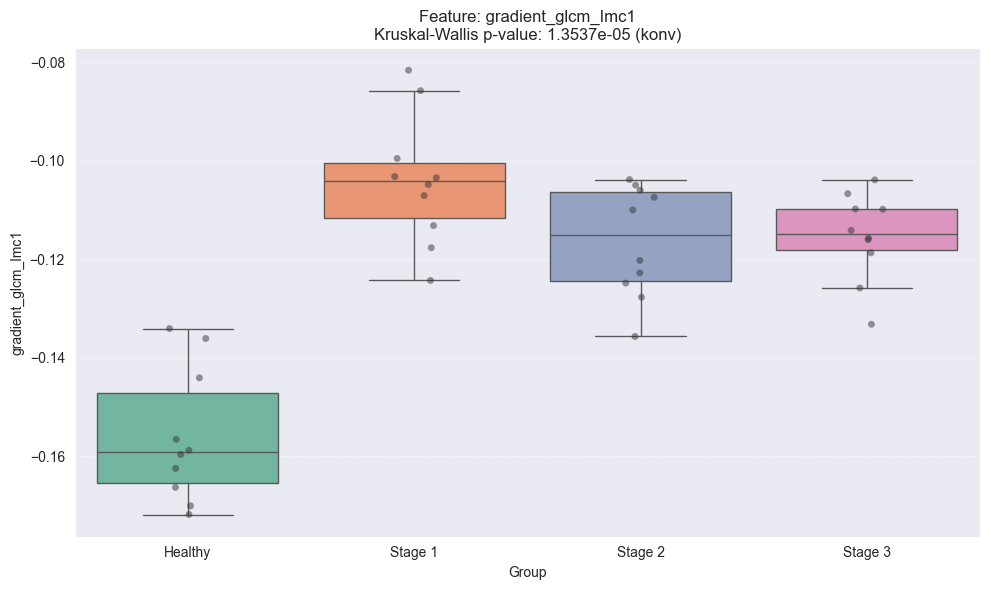

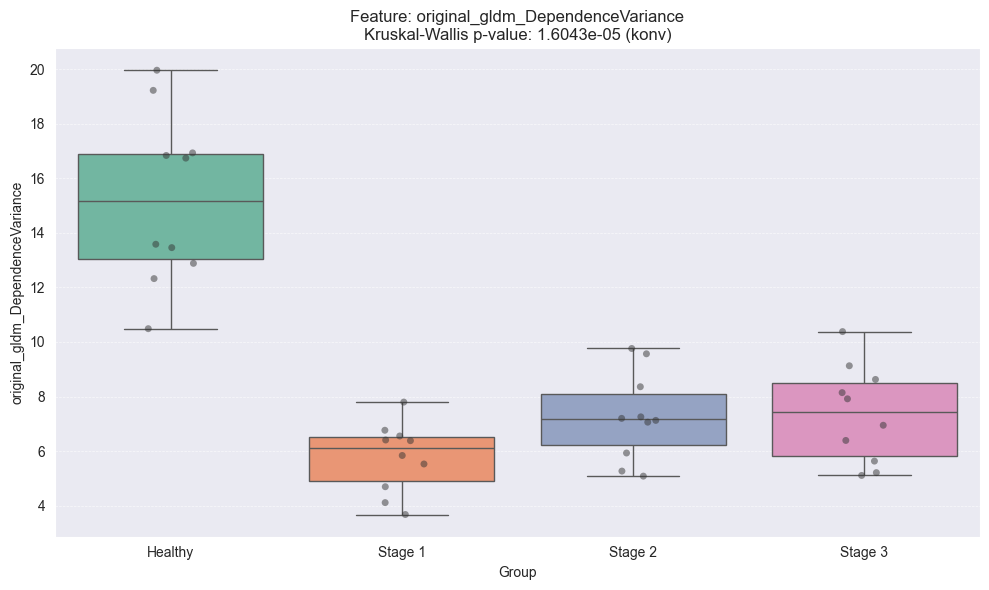

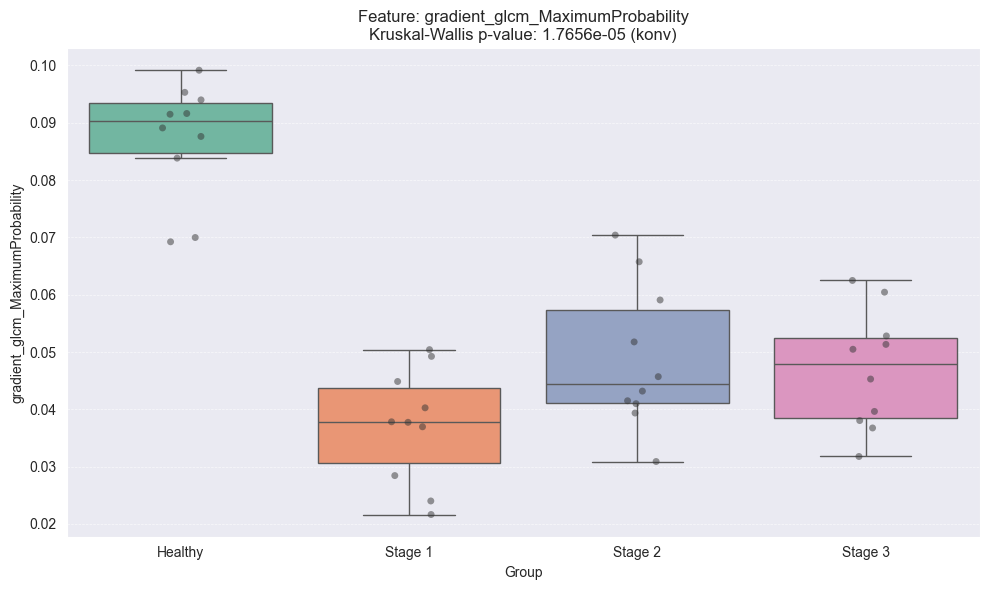

In [3]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
sns.set_style("darkgrid")
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "konv"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(3).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e} ({selected_img})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

boxpoty všetky MM vs Healthy

Najlepší príznak pre CaSupp_25: original_gldm_DependenceNonUniformity (p = 4.4005e-06)
Najlepší príznak pre konv: original_firstorder_10Percentile (p = 2.7907e-06)
Najlepší príznak pre monoe_40kev: original_firstorder_10Percentile (p = 3.2421e-06)


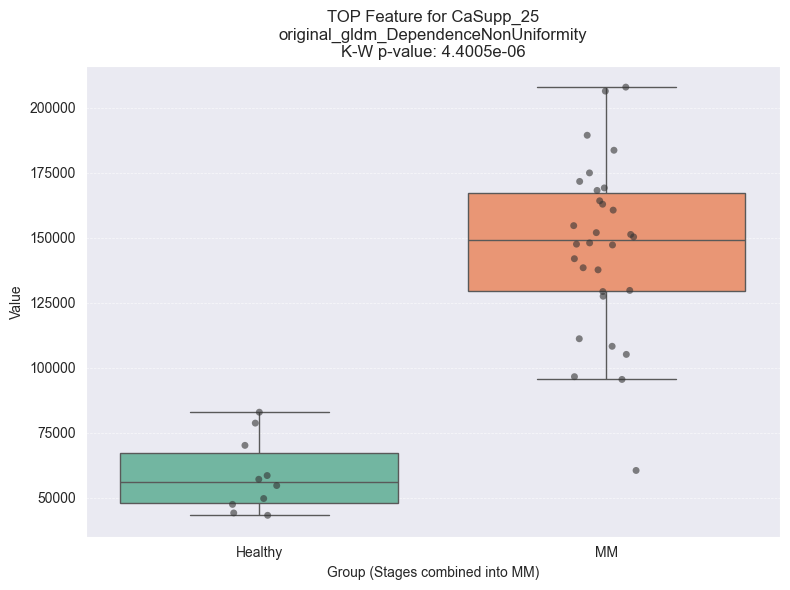

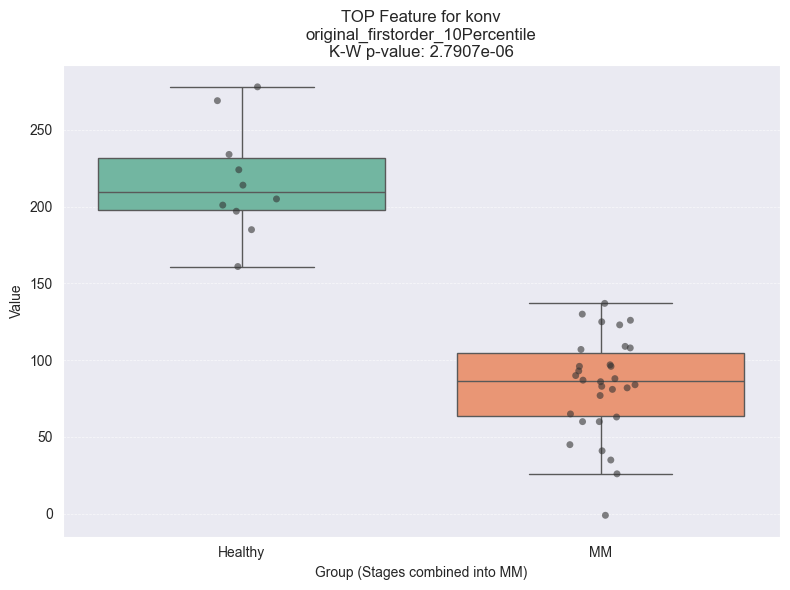

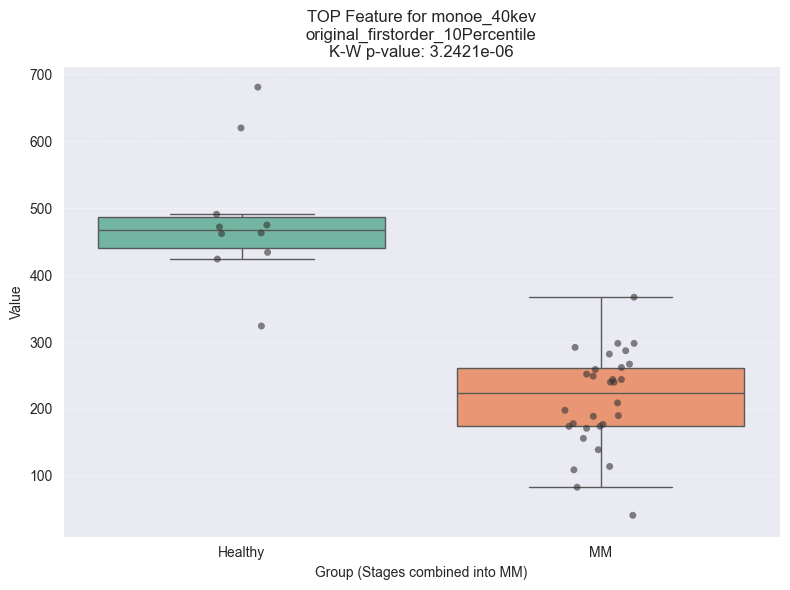

In [4]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie štýlu
sns.set_style("darkgrid")

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups_config = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "MM",
    "DATA_MM_Stage2": "MM",
    "DATA_MM_Stage3": "MM"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups_config.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label  # Tu sa Stage 1/2/3 zmení na "MM"
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA A VYKRESLENIE PRE KAŽDÝ TYP OBRAZU
# Pripravíme si zoznam pre ukladanie top výsledkov
final_visualizations = []

for selected_img in image_types:
    analysis_df = full_df[full_df['ImageType'] == selected_img].copy()
    features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

    stats_results = []

    for feat in features:
        # Kontrola variability
        if analysis_df[feat].nunique() <= 1:
            continue

        # Rozdelenie na 2 skupiny: Healthy vs MM
        g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
        g_mm = analysis_df[analysis_df['Group'] == "MM"][feat]

        if len(g_h) < 2 or len(g_mm) < 2:
            continue

        try:
            # K-W test pre 2 skupiny (ekvivalent Mann-Whitney U)
            h_stat, p_val = kruskal(g_h, g_mm)
            if not np.isnan(p_val):
                stats_results.append({'Feature': feat, 'p-value': p_val, 'ImageType': selected_img})
        except:
            continue

    if stats_results:
        # Zoradenie a výber TOP 1 príznaku pre tento ImageType
        results_df = pd.DataFrame(stats_results).sort_values('p-value')
        best_feature = results_df.iloc[0] # Prvý riadok je najlepší
        final_visualizations.append(best_feature)

        print(f"Najlepší príznak pre {selected_img}: {best_feature['Feature']} (p = {best_feature['p-value']:.4e})")

# 4. VYKRESLENIE TOP 1 PRÍZNAKU PRE KAŽDÝ OBRAZ
for item in final_visualizations:
    feat = item['Feature']
    img_type = item['ImageType']
    p_val = item['p-value']

    # Filtrujeme dáta len pre daný typ obrazu
    plot_df = full_df[full_df['ImageType'] == img_type]

    plt.figure(figsize=(8, 6))

    # Boxplot
    sns.boxplot(
        data=plot_df,
        x='Group',
        y=feat,
        hue='Group',
        order=["Healthy", "MM"],
        palette={"Healthy": "#66c2a5", "MM": "#fc8d62"}, # Fixné farby
        showfliers=False,
        legend=False
    )

    # Stripplot
    sns.stripplot(
        data=plot_df,
        x='Group',
        y=feat,
        hue='Group',
        order=["Healthy", "MM"],
        palette=["#333333"] * 2,
        alpha=0.6,
        legend=False
    )

    plt.title(f"TOP Feature for {img_type}\n{feat}\nK-W p-value: {p_val:.4e}")
    plt.xlabel("Group (Stages combined into MM)")
    plt.ylabel("Value")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

Skúsiť nejaký Threshold (Healthy vs MM || 1,2,3) - klasifikace, nejaký klasifikátor

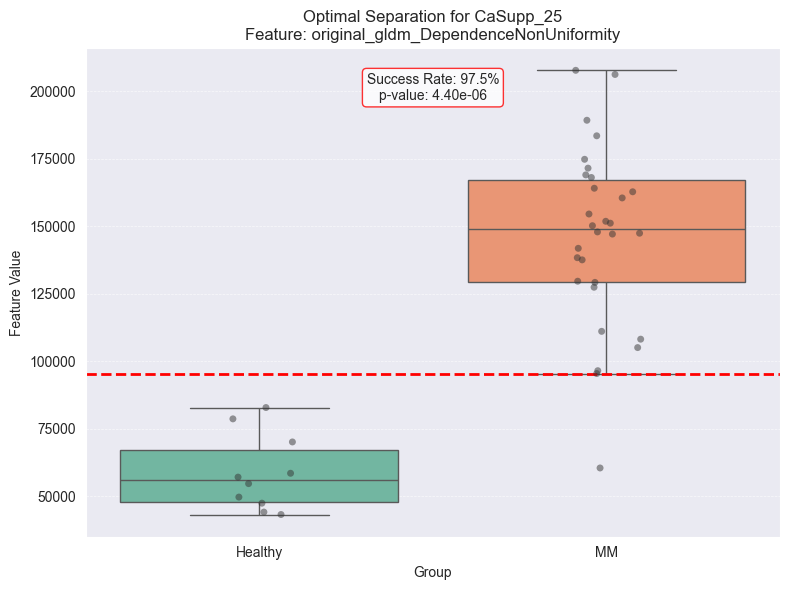

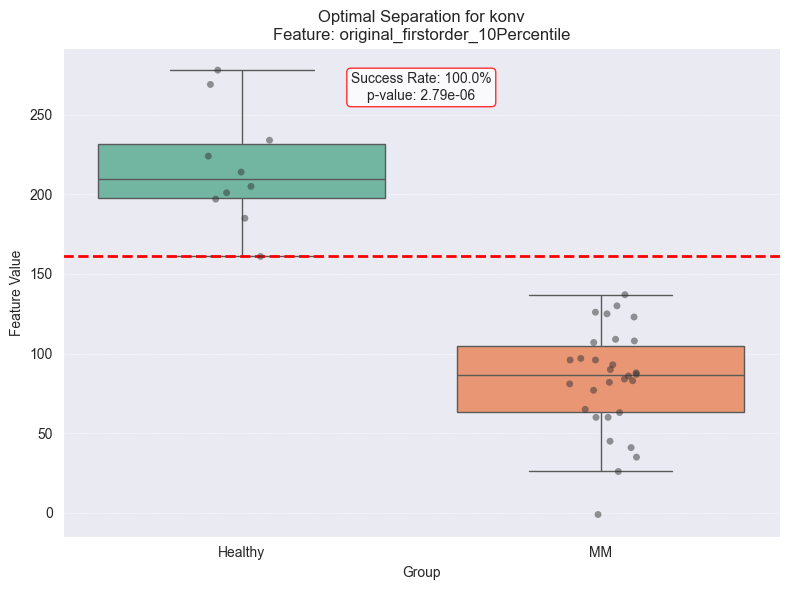

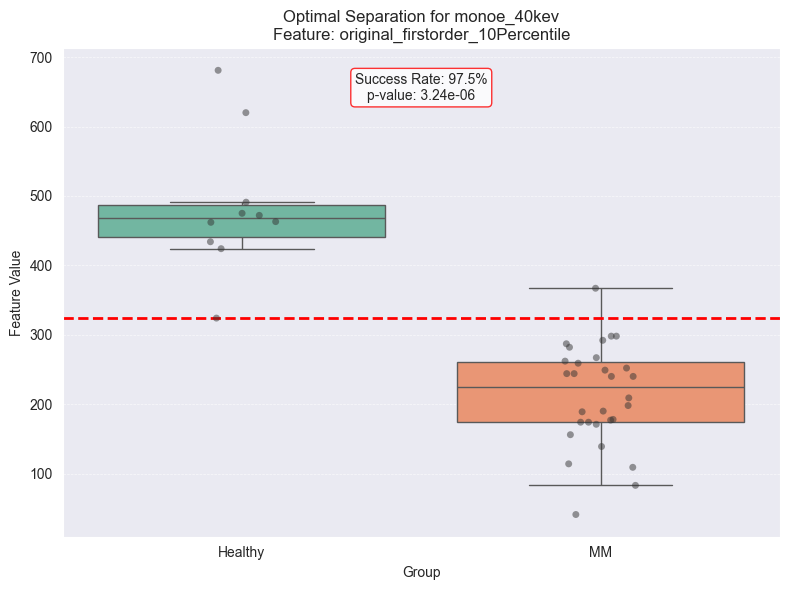

In [5]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

# 1. NASTAVENIA CESTY A SKUPÍN (Rovnaké ako predtým)
main_path = r"E:\DATA_Healthy_and_Myelom"
groups_config = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "MM",
    "DATA_MM_Stage2": "MM",
    "DATA_MM_Stage3": "MM"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT (Rovnaké ako predtým)
all_data = []
for group_folder, group_label in groups_config.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue
    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue
        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                img_type = None
                for it in image_types:
                    if it in file: img_type = it; break
                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    all_data.append(df_temp)

full_df = pd.concat(all_data, ignore_index=True)

# POMOCNÁ FUNKCIA NA HĽADANIE OPTIMÁLNEHO THRESHOLDU
def find_best_threshold(df, feature):
    # Skúsime všetky unikátne hodnoty príznaku ako potenciálne prahy
    thresholds = np.unique(df[feature])
    best_acc = 0
    best_thr = 0
    best_direction = ">" # Či MM sú nad alebo pod prahom

    for thr in thresholds:
        # Smer 1: MM sú tie, ktoré sú VÄČŠIE ako threshold
        preds_1 = np.where(df[feature] >= thr, "MM", "Healthy")
        acc_1 = np.mean(preds_1 == df["Group"])

        # Smer 2: MM sú tie, ktoré sú MENŠIE ako threshold
        preds_2 = np.where(df[feature] < thr, "MM", "Healthy")
        acc_2 = np.mean(preds_2 == df["Group"])

        if acc_1 > best_acc:
            best_acc = acc_1
            best_thr = thr
            best_direction = ">="
        if acc_2 > best_acc:
            best_acc = acc_2
            best_thr = thr
            best_direction = "<"

    return best_thr, best_acc * 100

# 3. ANALÝZA A VYKRESLENIE S THRESHOLDOM
for selected_img in image_types:
    analysis_df = full_df[full_df['ImageType'] == selected_img].copy()
    features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

    stats_results = []
    for feat in features:
        if analysis_df[feat].nunique() <= 1: continue
        g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
        g_mm = analysis_df[analysis_df['Group'] == "MM"][feat]
        try:
            h_stat, p_val = kruskal(g_h, g_mm)
            if not np.isnan(p_val):
                stats_results.append({'Feature': feat, 'p-value': p_val})
        except: continue

    if stats_results:
        # Vyberieme najlepší príznak
        top_feat_name = pd.DataFrame(stats_results).sort_values('p-value').iloc[0]['Feature']
        p_val_top = pd.DataFrame(stats_results).sort_values('p-value').iloc[0]['p-value']

        # Nájdenie thresholdu
        threshold, accuracy = find_best_threshold(analysis_df, top_feat_name)

        # VYKRESLENIE
        plt.figure(figsize=(8, 6))

        sns.boxplot(data=analysis_df, x='Group', y=top_feat_name, hue='Group',
                    order=["Healthy", "MM"], palette={"Healthy": "#66c2a5", "MM": "#fc8d62"},
                    showfliers=False, legend=False)

        sns.stripplot(data=analysis_df, x='Group', y=top_feat_name, hue='Group',
                      order=["Healthy", "MM"], palette=["#333333"] * 2, alpha=0.5, legend=False)

        # Čiara thresholdu
        plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f"Threshold: {threshold:.2f}")

        # Text s úspešnosťou
        # Umiestnime text do pravého horného rohu grafu
        plt.text(0.5, 0.95, f"Success Rate: {accuracy:.1f}%\np-value: {p_val_top:.2e}",
                 transform=plt.gca().transAxes, ha="center", va="top",
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="red"))

        plt.title(f"Optimal Separation for {selected_img}\nFeature: {top_feat_name}")
        plt.ylabel("Feature Value")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

- Dependence Non-Uniformity (DNU): Hodnotí, jak moc se od sebe liší počty těchto závislých sousedů napříč celou oblastí zájmu (ROI).
- Vysoká hodnota DNU: Naznačuje heterogenní texturu s velkou variabilitou v počtu závislých sousedů (neuniformní rozdělení závislostí).
- Nízká hodnota DNU: Indikuje uniformnější texturu, kde mají voxely podobný počet závislých sousedů.

Zobraziť len zdravé (boxploty) - Healhy vs MM (Vertebrae)

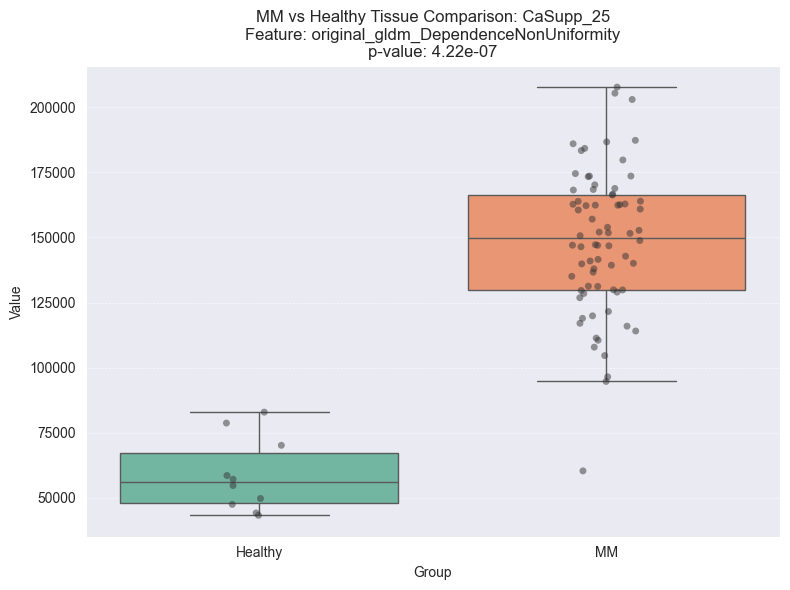

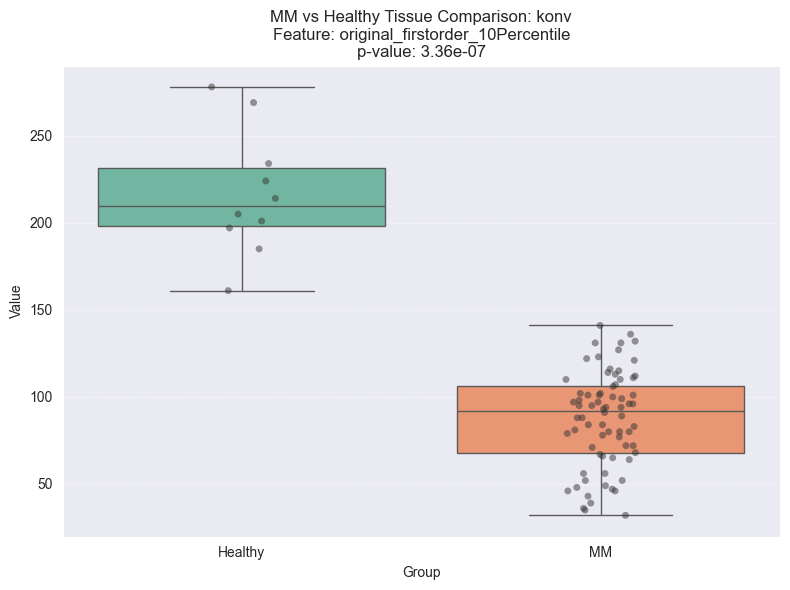

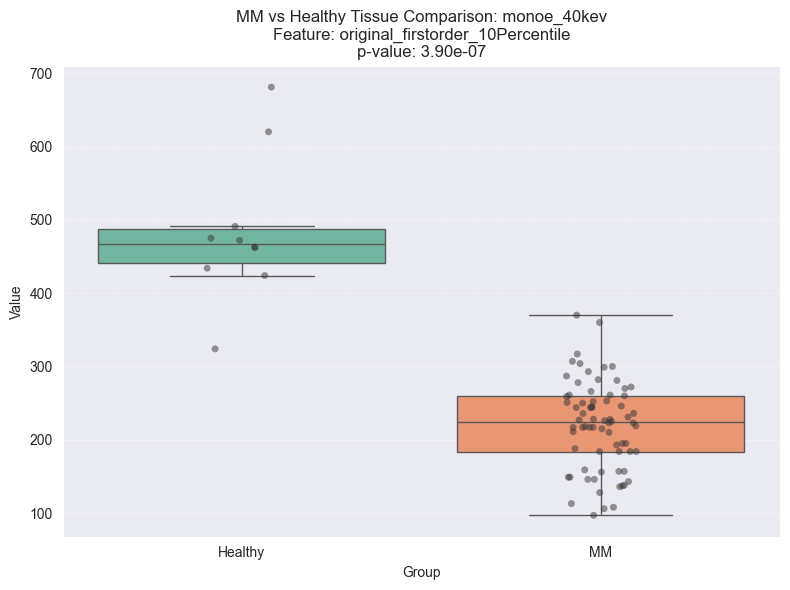

In [6]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie štýlu
sns.set_style("darkgrid")

# 1. NASTAVENIA CIEST
healthy_base_path = r"E:\DATA_Healthy_and_Myelom\DATA_Healthy"
myeloma_base_path = r"E:\DATA_Myelomy"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

# --- A: Načítanie Healthy (pôvodná cesta) ---
if os.path.exists(healthy_base_path):
    for patient_folder in os.listdir(healthy_base_path):
        patient_path = os.path.join(healthy_base_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Hľadáme typ obrazu v názve súboru
                img_type = next((it for it in image_types if it in file), None)
                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = 'Healthy'
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# --- B: Načítanie MM (nová cesta DATA_Myelomy) ---
if os.path.exists(myeloma_base_path):
    for patient_folder in os.listdir(myeloma_base_path):
        patient_path = os.path.join(myeloma_base_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            # Formát: ImageType_radiomics_spine_vertebrae_features.csv
            if "radiomics_spine_vertebrae_features.csv" in file:
                # Kontrolujeme, či súbor začína typom obrazu
                img_type = next((it for it in image_types if file.startswith(it)), None)
                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = 'MM'
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

if not all_data:
    print("Neboli nájdené žiadne dáta. Skontroluj cesty k priečinkom.")
else:
    full_df = pd.concat(all_data, ignore_index=True)

    # 3. ANALÝZA A VYKRESLENIE
    for selected_img in image_types:
        # Filtrujeme dáta pre konkrétny typ obrazu
        analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

        if analysis_df.empty:
            print(f"Žiadne dáta pre typ obrazu: {selected_img}")
            continue

        # Zoznam príznakov na testovanie
        features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

        stats_results = []
        for feat in features:
            if analysis_df[feat].nunique() <= 1: continue

            g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
            g_mm = analysis_df[analysis_df['Group'] == "MM"][feat]

            if len(g_h) < 2 or len(g_mm) < 2: continue

            try:
                # Kruskal-Wallis test
                h_stat, p_val = kruskal(g_h, g_mm)
                if not np.isnan(p_val):
                    stats_results.append({'Feature': feat, 'p-value': p_val})
            except:
                continue

        if stats_results:
            # Výber najlepšieho príznaku (najnižšia p-hodnota)
            top_res = pd.DataFrame(stats_results).sort_values('p-value').iloc[0]
            feat_name = top_res['Feature']
            p_val = top_res['p-value']

            # 4. VYKRESLENIE
            plt.figure(figsize=(8, 6))

            # Boxplot
            sns.boxplot(
                data=analysis_df,
                x='Group',
                y=feat_name,
                hue='Group',
                order=["Healthy", "MM"],
                palette={"Healthy": "#66c2a5", "MM": "#fc8d62"},
                showfliers=False,
                legend=False
            )

            # Stripplot (jednotliví pacienti)
            sns.stripplot(
                data=analysis_df,
                x='Group',
                y=feat_name,
                hue='Group',
                order=["Healthy", "MM"],
                palette=["#333333"] * 2,
                alpha=0.5,
                legend=False
            )

            plt.title(f"MM vs Healthy Tissue Comparison: {selected_img}\nFeature: {feat_name}\np-value: {p_val:.2e}")
            plt.ylabel("Value")
            plt.xlabel("Group")
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            plt.tight_layout()
            plt.show()
        else:
            print(f"Nepodarilo sa vypočítať štatistiku pre: {selected_img}")

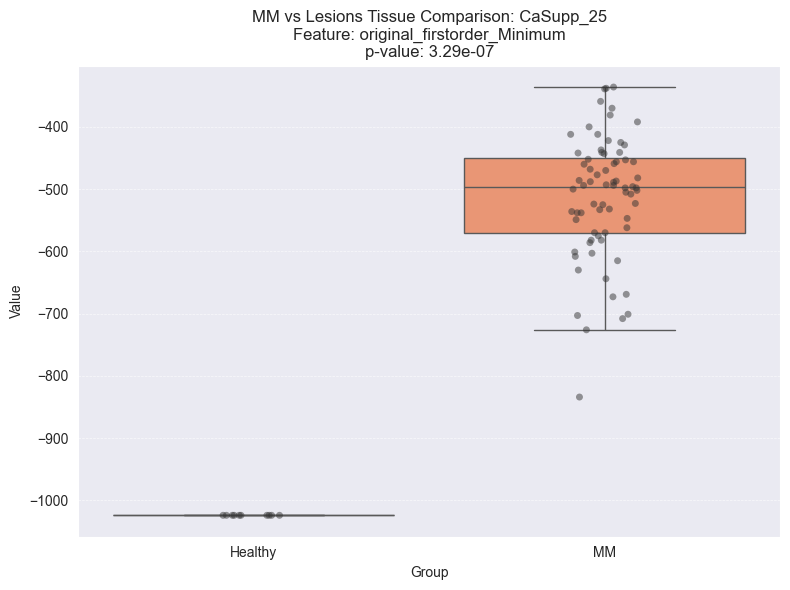

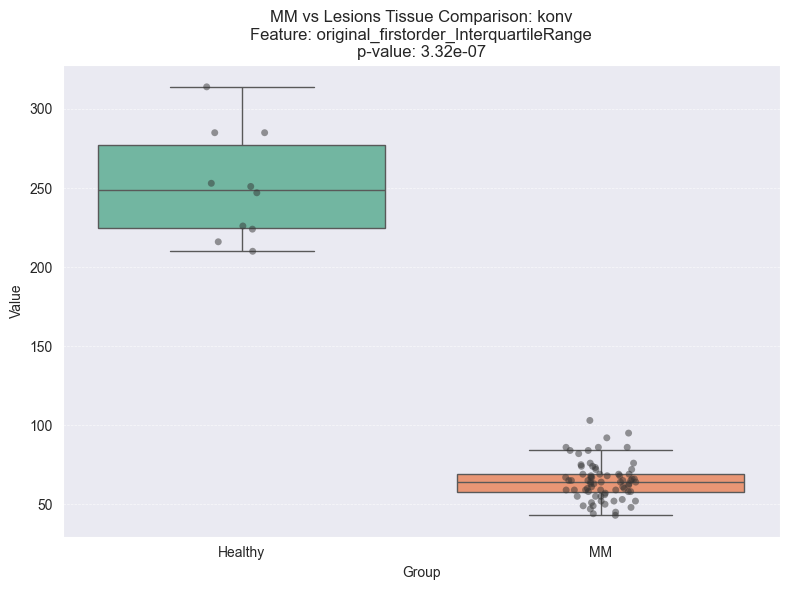

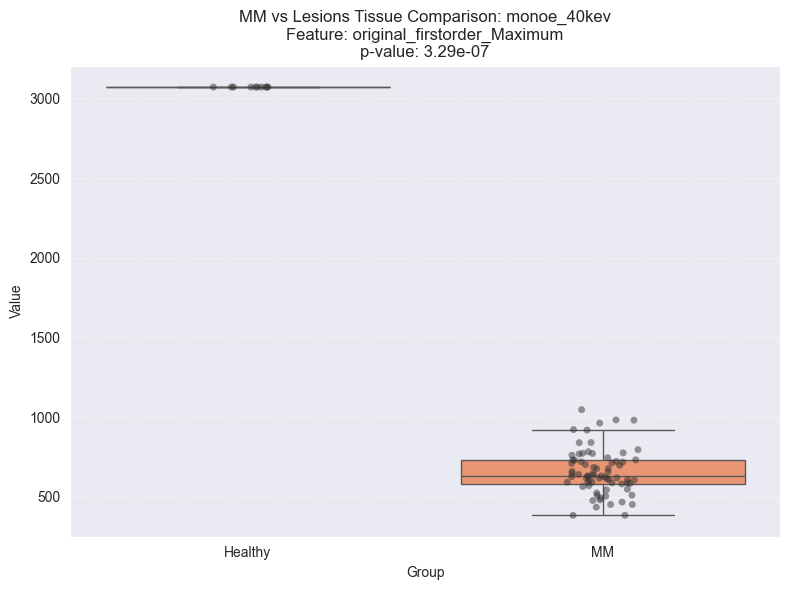

In [7]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie štýlu
sns.set_style("darkgrid")

# 1. NASTAVENIA CIEST
healthy_base_path = r"E:\DATA_Healthy_and_Myelom\DATA_Healthy"
myeloma_base_path = r"E:\DATA_Myelomy"

image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

# --- A: Načítanie Healthy (pôvodná cesta) ---
if os.path.exists(healthy_base_path):
    for patient_folder in os.listdir(healthy_base_path):
        patient_path = os.path.join(healthy_base_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Hľadáme typ obrazu v názve súboru
                img_type = next((it for it in image_types if it in file), None)
                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = 'Healthy'
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# --- B: Načítanie MM (nová cesta DATA_Myelomy) ---
if os.path.exists(myeloma_base_path):
    for patient_folder in os.listdir(myeloma_base_path):
        patient_path = os.path.join(myeloma_base_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            # Formát: ImageType_radiomics_spine_vertebrae_features.csv
            if "radiomics_spine_lesions_features.csv" in file:
                # Kontrolujeme, či súbor začína typom obrazu
                img_type = next((it for it in image_types if file.startswith(it)), None)
                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = 'MM'
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

if not all_data:
    print("Neboli nájdené žiadne dáta. Skontroluj cesty k priečinkom.")
else:
    full_df = pd.concat(all_data, ignore_index=True)

    # 3. ANALÝZA A VYKRESLENIE
    for selected_img in image_types:
        # Filtrujeme dáta pre konkrétny typ obrazu
        analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

        if analysis_df.empty:
            print(f"Žiadne dáta pre typ obrazu: {selected_img}")
            continue

        # Zoznam príznakov na testovanie
        features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

        stats_results = []
        for feat in features:
            if analysis_df[feat].nunique() <= 1: continue

            g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
            g_mm = analysis_df[analysis_df['Group'] == "MM"][feat]

            if len(g_h) < 2 or len(g_mm) < 2: continue

            try:
                # Kruskal-Wallis test
                h_stat, p_val = kruskal(g_h, g_mm)
                if not np.isnan(p_val):
                    stats_results.append({'Feature': feat, 'p-value': p_val})
            except:
                continue

        if stats_results:
            # Výber najlepšieho príznaku (najnižšia p-hodnota)
            top_res = pd.DataFrame(stats_results).sort_values('p-value').iloc[0]
            feat_name = top_res['Feature']
            p_val = top_res['p-value']

            # 4. VYKRESLENIE
            plt.figure(figsize=(8, 6))

            # Boxplot
            sns.boxplot(
                data=analysis_df,
                x='Group',
                y=feat_name,
                hue='Group',
                order=["Healthy", "MM"],
                palette={"Healthy": "#66c2a5", "MM": "#fc8d62"},
                showfliers=False,
                legend=False
            )

            # Stripplot (jednotliví pacienti)
            sns.stripplot(
                data=analysis_df,
                x='Group',
                y=feat_name,
                hue='Group',
                order=["Healthy", "MM"],
                palette=["#333333"] * 2,
                alpha=0.5,
                legend=False
            )

            plt.title(f"MM vs Lesions Tissue Comparison: {selected_img}\nFeature: {feat_name}\np-value: {p_val:.2e}")
            plt.ylabel("Value")
            plt.xlabel("Group")
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            plt.tight_layout()
            plt.show()
        else:
            print(f"Nepodarilo sa vypočítať štatistiku pre: {selected_img}")

Skúsiť len na Thoracic

Eliminace skrytých premenných (šum) - podívať se, skontrolovať dáta

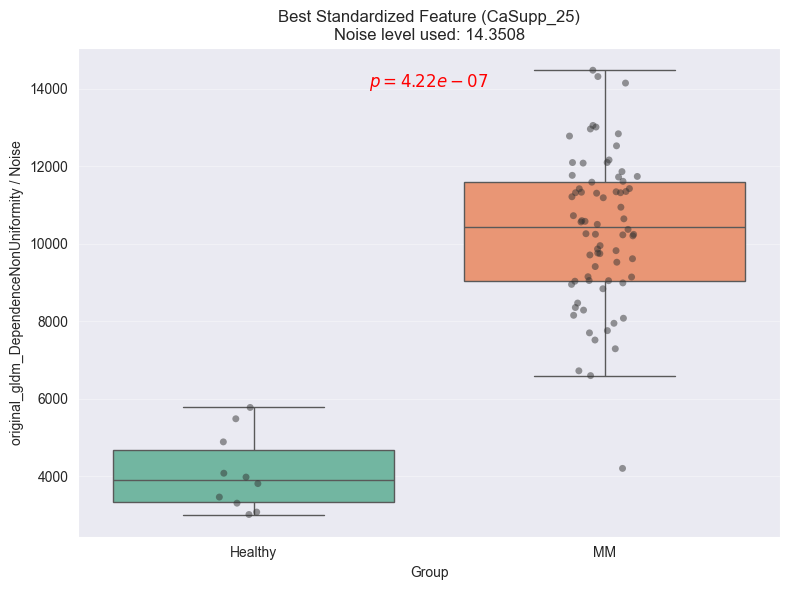

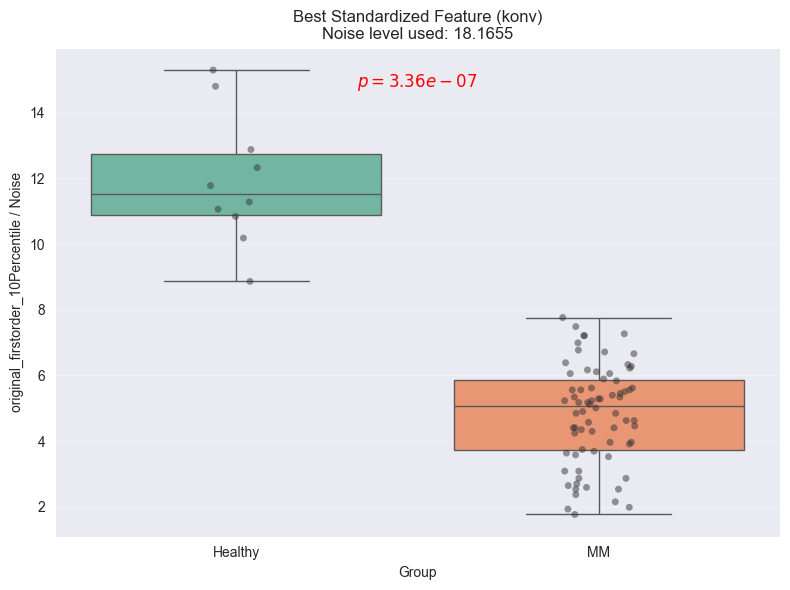

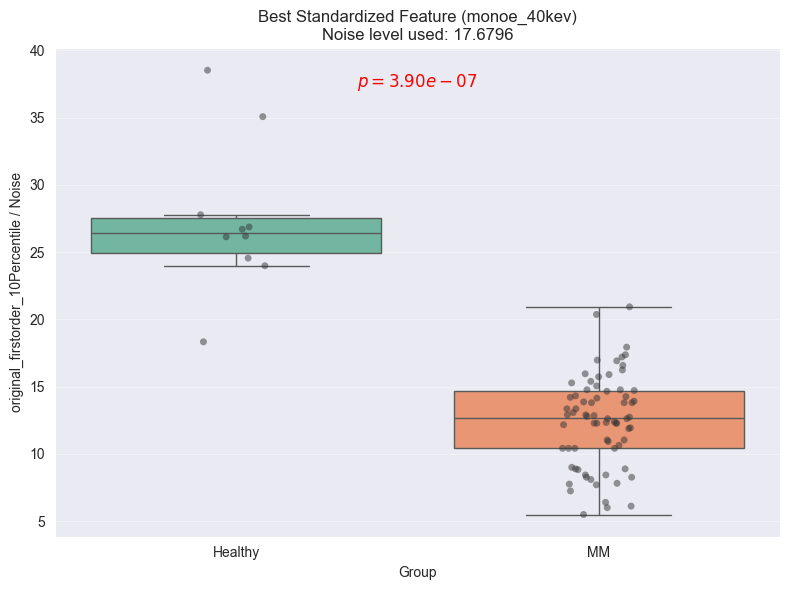

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie štýlu
sns.set_style("darkgrid")

# 1. KONFIGURÁCIA FIXNÉHO ŠUMU
NOISE_MAP = {
    "CaSupp_25": 14.350816654962419,
    "konv": 18.16551213166482,
    "monoe_40kev": 17.67958787665536,
}

# 2. CESTY K DÁTAM
healthy_base_path = r"E:\DATA_Healthy_and_Myelom\DATA_Healthy"
myeloma_base_path = r"E:\DATA_Myelomy"
image_types = list(NOISE_MAP.keys())

# 3. NAČÍTANIE A ŠTANDARDIZÁCIA DÁT
all_data = []

def process_and_standardize(folder_path, group_label, file_suffix):
    """Pomocná funkcia na načítanie a podelenie šumom s opravou fragmentácie."""
    local_data = []
    if not os.path.exists(folder_path):
        return local_data

    for patient_folder in os.listdir(folder_path):
        patient_path = os.path.join(folder_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith(file_suffix):
                img_type = next((it for it in image_types if it in file), None)
                if img_type:
                    # Načítanie dát
                    df_temp = pd.read_csv(os.path.join(patient_path, file))

                    # Fixný šum pre tento typ obrazu
                    noise_val = NOISE_MAP[img_type]

                    # Štandardizácia: Vydelíme všetky číselné stĺpce (príznaky)
                    num_cols = df_temp.select_dtypes(include=[np.number]).columns
                    df_temp[num_cols] = df_temp[num_cols] / noise_val

                    # --- OPRAVA FRAGMENTÁCIE ---
                    # Pridávame metadáta naraz a vytvoríme čerstvú kópiu v pamäti
                    df_temp = df_temp.assign(
                        Group=group_label,
                        ImageType=img_type,
                        Patient=patient_folder
                    ).copy()
                    # ----------------------------

                    local_data.append(df_temp)
    return local_data

# Načítame obe skupiny
all_data.extend(process_and_standardize(healthy_base_path, "Healthy", "radiomics_spine_features.csv"))
all_data.extend(process_and_standardize(myeloma_base_path, "MM", "radiomics_spine_vertebrae_features.csv"))

if not all_data:
    print("Žiadne dáta sa nenašli. Skontroluj cesty!")
else:
    # Spojenie do jedného veľkého DataFrame
    full_df = pd.concat(all_data, ignore_index=True)

    # 4. ŠTATISTICKÁ ANALÝZA A VYKRESLENIE
    for selected_img in image_types:
        analysis_df = full_df[full_df['ImageType'] == selected_img].copy()
        features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

        stats_results = []
        for feat in features:
            if analysis_df[feat].nunique() <= 1: continue

            g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
            g_mm = analysis_df[analysis_df['Group'] == "MM"][feat]

            if len(g_h) < 2 or len(g_mm) < 2: continue

            try:
                _, p_val = kruskal(g_h, g_mm)
                if not np.isnan(p_val):
                    stats_results.append({'Feature': feat, 'p-value': p_val})
            except: continue

        if stats_results:
            # Výber najlepšieho príznaku
            top_feat = pd.DataFrame(stats_results).sort_values('p-value').iloc[0]
            feat_name = top_feat['Feature']
            p_val_val = top_feat['p-value']

            # VYKRESLENIE
            plt.figure(figsize=(8, 6))

            sns.boxplot(
                data=analysis_df, x='Group', y=feat_name, hue='Group',
                order=["Healthy", "MM"], palette={"Healthy": "#66c2a5", "MM": "#fc8d62"},
                showfliers=False, legend=False
            )

            sns.stripplot(
                data=analysis_df, x='Group', y=feat_name, hue='Group',
                order=["Healthy", "MM"], palette=["#333333"] * 2, alpha=0.5, legend=False
            )

            plt.title(f"Best Standardized Feature ({selected_img})\nNoise level used: {NOISE_MAP[selected_img]:.4f}")
            plt.ylabel(f"{feat_name} / Noise")

            # Pridanie textu s p-hodnotou priamo do grafu
            plt.annotate(f"$p = {p_val_val:.2e}$", xy=(0.5, 0.92), xycoords='axes fraction',
                         ha='center', fontsize=12, fontweight='bold', color='red')

            plt.tight_layout()
            plt.show()